# NSA.3 – Análisis No Supervisado: Agrupación (Clustering)
## Dataset: `cliente_tienda.csv`
## Alumno: Santiago González Aguirre
## Fecha: 2026-08-19
---

## 1. Justificación del Algoritmo

Se seleccionó **K-Means** por las siguientes razones:

- El dataset `cliente_tienda.csv` contiene **variables numéricas continuas** (Edad, Ingresos, Porcentaje de Gastos) que se prestan naturalmente a la partición por distancia euclidiana, que es el fundamento de K-Means.
- El objetivo es encontrar **segmentos de clientes** con comportamiento de compra similar, una tarea clásica de segmentación de mercado donde K-Means es el estándar de la industria.
- Con **200 registros**, K-Means es computacionalmente eficiente y produce resultados reproducibles con semilla fija.
- Permite el uso del **Método del Codo** y el **Coeficiente de Silhouette** para determinar el número óptimo de clusters.
- Los resultados son fácilmente interpretables en un plano 2D al graficar los centroides.

**Alternativas descartadas:** DBSCAN (útil para clusters de forma irregular, no aplica aquí), Jerárquico (computacionalmente costoso sin ventaja en este contexto), GMM (mayor complejidad sin beneficio claro con datos centroidales).

## 2. Paso 1 – Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#13111c',
    'axes.facecolor': '#1c1930',
    'axes.edgecolor': '#2d2b4e',
    'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#e2e8f0',
    'ytick.color': '#e2e8f0',
    'text.color': '#e2e8f0',
    'grid.color': '#2d2b4e',
    'grid.alpha': 0.5,
})

# Paleta para clusters (hasta 6 grupos)
CLUSTER_COLORS = ['#7c3aed', '#06b6d4', '#f59e0b', '#10b981', '#ef4444', '#3b82f6']

print('Librerías cargadas ✓')

Librerías cargadas ✓


## 3. Paso 2 – Carga y exploración del dataset

In [2]:
df = pd.read_csv('cliente_tienda.csv')

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print()
df.describe()

Shape: (200, 5)
Columnas: ['CustomerID', 'Genero', 'Edad', 'Ingresos Anuales ($)', 'Porcentajde de gastos (1-100)']
Valores nulos: 0



,CustomerID,Edad,Ingresos Anuales ($),Porcentajde de gastos (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
# Distribución de género
print('Distribución de Género:')
print(df['Genero'].value_counts())
df.head(10)

Distribución de Género:
Genero
Female    112
Male       88
Name: count, dtype: int64


,CustomerID,Genero,Edad,Ingresos Anuales ($),Porcentajde de gastos (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 4. Paso 3 – Preprocesamiento

In [4]:
# Seleccionar características para clustering
# Usamos las 3 variables numéricas relevantes para segmentación
feature_cols = ['Edad', 'Ingresos Anuales ($)', 'Porcentajde de gastos (1-100)']
X = df[feature_cols].copy()

# Escalar: K-Means es sensible a la escala de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Datos escalados (primeras 5 filas):')
print(pd.DataFrame(X_scaled, columns=feature_cols).head())
print(f'\nMedia después de escalar: {X_scaled.mean(axis=0).round(6)}')
print(f'Std después de escalar:   {X_scaled.std(axis=0).round(4)}')

Datos escalados (primeras 5 filas):
       Edad  Ingresos Anuales ($)  Porcentajde de gastos (1-100)
0 -1.424569             -1.738999                      -0.434801
1 -1.281035             -1.738999                       1.195704
2 -1.352802             -1.700830                      -1.715913
3 -1.137502             -1.700830                       1.040418
4 -0.563369             -1.662660                      -0.395980

Media después de escalar: [-0. -0. -0.]
Std después de escalar:   [1. 1. 1.]


## 5. Paso 4 – Método del Codo + Silhouette para determinar K óptimo

In [5]:
k_range = range(2, 11)
inertias = []
silhouettes = []
db_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# Tabla de métricas
metrics_df = pd.DataFrame({
    'K': list(k_range),
    'Inercia (WCSS)': [f'{v:.2f}' for v in inertias],
    'Silhouette ↑': [f'{v:.4f}' for v in silhouettes],
    'Davies-Bouldin ↓': [f'{v:.4f}' for v in db_scores],
    'Calinski-Harabasz ↑': [f'{v:.2f}' for v in ch_scores]
})
print('=== MÉTRICAS POR NÚMERO DE CLUSTERS ===')
print(metrics_df.to_string(index=False))

k_opt_sil = list(k_range)[silhouettes.index(max(silhouettes))]
k_opt_db  = list(k_range)[db_scores.index(min(db_scores))]
print(f'\n→ K óptimo por Silhouette: {k_opt_sil} (Silhouette = {max(silhouettes):.4f})')
print(f'→ K óptimo por Davies-Bouldin: {k_opt_db}')

=== MÉTRICAS POR NÚMERO DE CLUSTERS ===
 K Inercia (WCSS) Silhouette ↑ Davies-Bouldin ↓ Calinski-Harabasz ↑
 2         389.39       0.3355           1.2607              107.10
 3         295.21       0.3578           1.0503              101.69
 4         205.23       0.4040           0.9308              125.68
 5         168.25       0.4166           0.8746              125.10
 6         133.87       0.4284           0.8254              135.10
 7         117.01       0.4172           0.7935              132.77
 8         103.87       0.4082           0.8918              131.01
 9          93.09       0.4177           0.8198              130.00
10          82.39       0.4066           0.8679              132.64

→ K óptimo por Silhouette: 6 (Silhouette = 0.4284)
→ K óptimo por Davies-Bouldin: 7


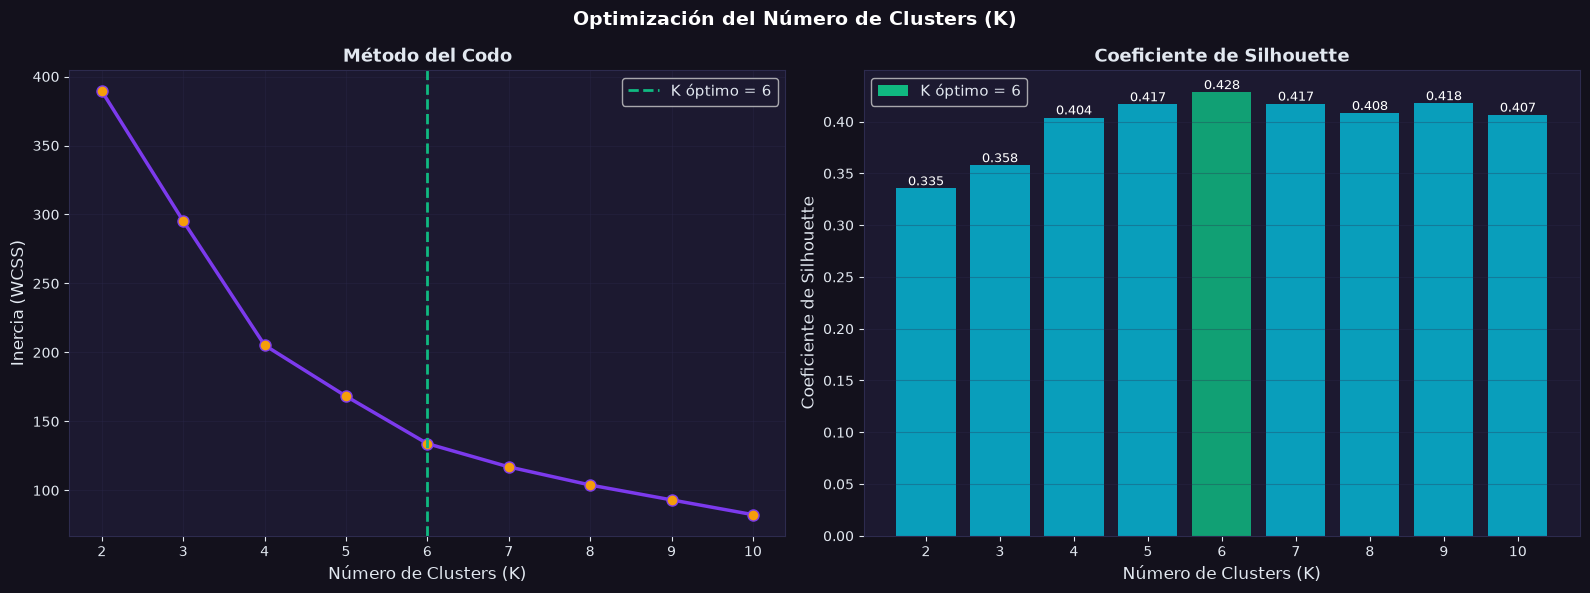

Gráfica guardada como NSA3_codo_silhouette.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimización del Número de Clusters (K)', fontsize=14, fontweight='bold', color='white')

# Método del Codo
ax1 = axes[0]
ax1.plot(k_range, inertias, 'o-', color='#7c3aed', linewidth=2.5, markersize=8, markerfacecolor='#f59e0b')
ax1.axvline(x=k_opt_sil, color='#10b981', linestyle='--', linewidth=2, label=f'K óptimo = {k_opt_sil}')
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia (WCSS)', fontsize=12)
ax1.set_title('Método del Codo', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(k_range))

# Silhouette Score
ax2 = axes[1]
bar_colors = ['#10b981' if k == k_opt_sil else '#06b6d4' for k in k_range]
bars = ax2.bar(k_range, silhouettes, color=bar_colors, alpha=0.85, edgecolor='none')
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.3f}',
             ha='center', fontsize=9, color='white')
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Coeficiente de Silhouette', fontsize=12)
ax2.set_title('Coeficiente de Silhouette', fontsize=13, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
ax2.legend(handles=[Patch(facecolor='#10b981', label=f'K óptimo = {k_opt_sil}')], fontsize=11)

plt.tight_layout()
plt.savefig('NSA3_codo_silhouette.png', dpi=150, bbox_inches='tight', facecolor='#13111c')
plt.show()
print('Gráfica guardada como NSA3_codo_silhouette.png')

## 6. Paso 5 – Entrenamiento del modelo K-Means optimizado

In [7]:
K_OPTIMO = k_opt_sil  # Usar el K sugerido por Silhouette

kmeans = KMeans(
    n_clusters=K_OPTIMO,
    init='k-means++',
    n_init=20,         # 20 inicializaciones aleatorias → elige la mejor
    max_iter=500,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'✓ K-Means entrenado con K = {K_OPTIMO}')
print(f'Silhouette Score final: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'Davies-Bouldin Score:   {davies_bouldin_score(X_scaled, df["Cluster"]):.4f}')
print(f'\nDistribución de clusters:')
print(df['Cluster'].value_counts().sort_index())

✓ K-Means entrenado con K = 6
Silhouette Score final: 0.4274
Davies-Bouldin Score:   0.8277

Distribución de clusters:
Cluster
0    33
1    45
2    24
3    39
4    38
5    21
Name: count, dtype: int64


## 7. Paso 6 – Análisis de los clusters

In [8]:
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster')[feature_cols].agg(['mean', 'std']).round(2)
print('=== PERFIL PROMEDIO POR CLUSTER ===')
print(cluster_stats)

print('\n=== DESCRIPCIÓN DE SEGMENTOS ===')
cluster_means = df.groupby('Cluster')[feature_cols].mean().round(1)
for i, row in cluster_means.iterrows():
    print(f'\nCluster {i}:')
    print(f'  Edad promedio:        {row["Edad"]:.1f} años')
    print(f'  Ingresos promedio:    ${row["Ingresos Anuales ($)"]:.1f}k')
    print(f'  Gasto promedio:       {row["Porcentajde de gastos (1-100)"]:.1f}/100')

=== PERFIL PROMEDIO POR CLUSTER ===
          Edad        Ingresos Anuales ($)         \
          mean    std                 mean    std   
Cluster                                             
0        41.94  10.18                88.94  16.59   
1        56.33   8.45                54.27   8.98   
2        25.25   5.33                25.83   8.06   
3        32.69   3.73                86.54  16.31   
4        26.68   7.12                57.58   9.85   
5        45.52  11.77                26.29   7.44   

        Porcentajde de gastos (1-100)         
                                 mean    std  
Cluster                                       
0                               16.97   9.96  
1                               49.07   6.30  
2                               76.92  13.42  
3                               82.13   9.36  
4                               47.79   9.87  
5                               19.38  12.56  

=== DESCRIPCIÓN DE SEGMENTOS ===

Cluster 0:
  Edad promedio: 

## 8. Paso 7 – Visualización de clusters

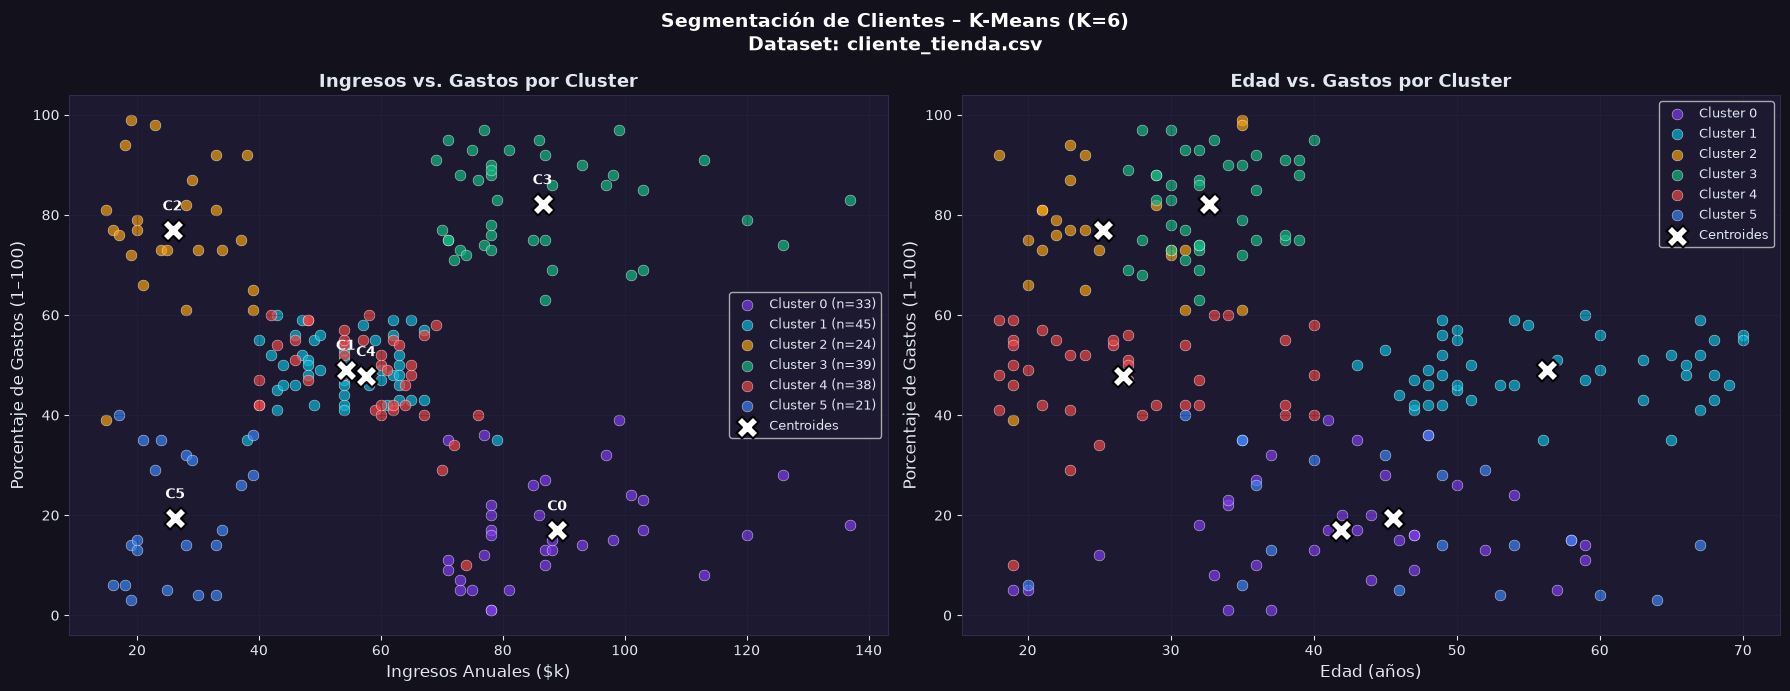

Gráfica guardada como NSA3_clusters.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Segmentación de Clientes – K-Means (K={K_OPTIMO})\nDataset: cliente_tienda.csv',
             fontsize=14, fontweight='bold', color='white')

# Desescalar centroides para interpretar
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

# --- Gráfica 1: Ingresos vs Gasto ---
ax1 = axes[0]
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    ax1.scatter(
        df.loc[mask, 'Ingresos Anuales ($)'],
        df.loc[mask, 'Porcentajde de gastos (1-100)'],
        color=CLUSTER_COLORS[cluster_id], alpha=0.7, s=60, edgecolors='white', linewidths=0.4,
        label=f'Cluster {cluster_id} (n={mask.sum()})'
    )

# Centroides
ax1.scatter(centroids_orig[:, 1], centroids_orig[:, 2],
            color='white', marker='X', s=250, linewidths=1.5,
            edgecolors='black', zorder=10, label='Centroides')
for i, (cx, cy) in enumerate(zip(centroids_orig[:, 1], centroids_orig[:, 2])):
    ax1.annotate(f'C{i}', (cx, cy), fontsize=10, fontweight='bold',
                 ha='center', va='bottom', color='white',
                 xytext=(0, 12), textcoords='offset points')

ax1.set_xlabel('Ingresos Anuales ($k)', fontsize=12)
ax1.set_ylabel('Porcentaje de Gastos (1–100)', fontsize=12)
ax1.set_title('Ingresos vs. Gastos por Cluster', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: Edad vs Gasto ---
ax2 = axes[1]
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    ax2.scatter(
        df.loc[mask, 'Edad'],
        df.loc[mask, 'Porcentajde de gastos (1-100)'],
        color=CLUSTER_COLORS[cluster_id], alpha=0.7, s=60, edgecolors='white', linewidths=0.4,
        label=f'Cluster {cluster_id}'
    )
ax2.scatter(centroids_orig[:, 0], centroids_orig[:, 2],
            color='white', marker='X', s=250, linewidths=1.5, edgecolors='black', zorder=10, label='Centroides')
ax2.set_xlabel('Edad (años)', fontsize=12)
ax2.set_ylabel('Porcentaje de Gastos (1–100)', fontsize=12)
ax2.set_title('Edad vs. Gastos por Cluster', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NSA3_clusters.png', dpi=150, bbox_inches='tight', facecolor='#13111c')
plt.show()
print('Gráfica guardada como NSA3_clusters.png')

## 9. Paso 8 – Gráfica de radar por perfil de cluster

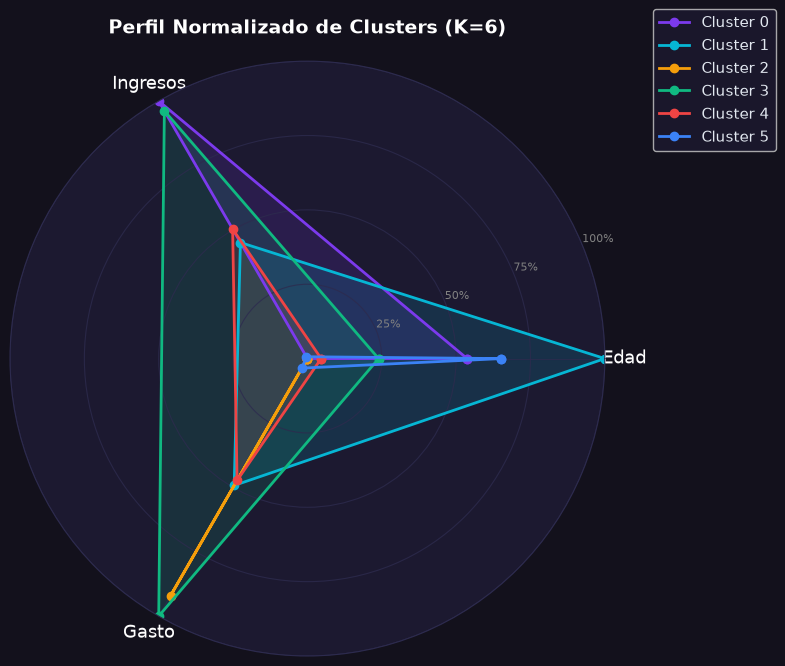

Gráfica guardada como NSA3_radar.png


In [10]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar para el gráfico de radar
cluster_means = df.groupby('Cluster')[feature_cols].mean()
norm = MinMaxScaler()
cluster_norm = pd.DataFrame(norm.fit_transform(cluster_means), columns=feature_cols, index=cluster_means.index)

labels_radar = ['Edad', 'Ingresos', 'Gasto']
N = len(labels_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#13111c')
ax.set_facecolor('#1c1930')

for i, row in cluster_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=CLUSTER_COLORS[i], label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.15, color=CLUSTER_COLORS[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=13, color='white')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax.grid(color='#2d2b4e', alpha=0.8)
ax.set_title(f'Perfil Normalizado de Clusters (K={K_OPTIMO})', fontsize=14, fontweight='bold', color='white', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('NSA3_radar.png', dpi=150, bbox_inches='tight', facecolor='#13111c')
plt.show()
print('Gráfica guardada como NSA3_radar.png')

## 10. Paso 9 – Guardar el modelo

In [11]:
joblib.dump(kmeans, 'NSA3_modelo_kmeans.pkl')
joblib.dump(scaler, 'NSA3_scaler.pkl')
print('✓ Modelo guardado: NSA3_modelo_kmeans.pkl')
print('✓ Scaler guardado: NSA3_scaler.pkl')

print(f'\n=== RESUMEN FINAL ===')
print(f'Algoritmo:            K-Means (k-means++)')
print(f'K óptimo:             {K_OPTIMO} clusters')
print(f'Silhouette Score:     {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'Davies-Bouldin Score: {davies_bouldin_score(X_scaled, df["Cluster"]):.4f}')
print(f'Inercia (WCSS):       {kmeans.inertia_:.2f}')

✓ Modelo guardado: NSA3_modelo_kmeans.pkl
✓ Scaler guardado: NSA3_scaler.pkl

=== RESUMEN FINAL ===
Algoritmo:            K-Means (k-means++)
K óptimo:             6 clusters
Silhouette Score:     0.4274
Davies-Bouldin Score: 0.8277
Inercia (WCSS):       133.87
